In [1]:
import os
import pandas as pd
from skimage.feature import hog
from skimage.color import rgb2gray, rgb2hsv
from skimage.transform import resize
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib

2026-05-16 11:37:02.431976: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 11:37:02.450882: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Importing models (PCA is now embedded in the pipeline)
svm_full = joblib.load("svm_model.joblib")
svm_bbox = joblib.load("svm_model_bounding_box.joblib")

In [3]:
# Create dataframes from dataset files
DATA_DIR = "CUB_200_2011"
IMAGES_DIR = os.path.join(DATA_DIR, "images")

# Load the metadata files
images_df = pd.read_csv(
    os.path.join(DATA_DIR, "images.txt"),
    sep=" ",
    names=["image_id", "image_path"]
)

labels_df = pd.read_csv(
    os.path.join(DATA_DIR, "image_class_labels.txt"),
    sep=" ",
    names=["image_id", "class_id"]
)

bbox_df = pd.read_csv(
    os.path.join(DATA_DIR, "bounding_boxes.txt"),
    sep=" ",
    names=["image_id", "x", "y", "width", "height"]
)

splt_df = pd.read_csv(
    os.path.join(DATA_DIR, "train_test_split.txt"),
    sep=" ",
    names=["image_id", "is_train"]
)

# Merge all the dataframes into a single frame called 'data'
data = images_df.merge(labels_df, on="image_id").merge(bbox_df, on="image_id").merge(splt_df, on="image_id")

unique_classes = sorted(data["class_id"].unique())
print(f"Number of unique classes: {len(unique_classes)}")

class_mapping = {old: new for new, old in enumerate(unique_classes)}

data["label"] = data["class_id"].map(class_mapping)

data["full_path"] = data["image_path"].apply(
    lambda x: os.path.join(IMAGES_DIR, x)
)

# Split data into training and testing sets
train_df = data[data["is_train"] == 1].reset_index(drop=True)
test_df = data[data["is_train"] == 0].reset_index(drop=True)

train_paths = train_df["full_path"].values
train_labels = train_df["label"].values
train_bboxes = train_df[["x", "y", "width", "height"]].values

test_paths = test_df["full_path"].values
test_labels = test_df["label"].values
test_bboxes = test_df[["x", "y", "width", "height"]].values

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))
print("Number of classes:", data["label"].nunique())

# Calculate most common size size of images in the dataset
most_common_width = int(data["image_path"].apply(lambda x: Image.open(os.path.join(IMAGES_DIR, x)).size[0]).mode()[0])
most_common_height = int(data["image_path"].apply(lambda x: Image.open(os.path.join(IMAGES_DIR, x)).size[1]).mode()[0])
most_common_size = (most_common_width, most_common_height)
print(f"Most common image size: {most_common_size}")

# While the most common size is (500, 500), I run out of RAM, so we'll need to need to resize the images to a smaller size like (300, 300)
most_common_size = (160, 160)


# Resize the image to a fixed size for consistent feature extraction
def resizeImage(image, target_size):
    return resize(image, target_size)


Number of unique classes: 200
Training samples: 5994
Testing samples: 5794
Number of classes: 200


Most common image size: (500, 500)


In [4]:

# Extract 
def extract_hog(image):
    
    # Convert to grayscale (HOG works on intensity gradients)
    gray = rgb2gray(image)

    # Extract HOG features (edge/shape descriptors)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )
    return features

def extract_HSV_histogram(image):
    # Convert to HSV color space
    hsv = rgb2hsv(image)

    # Compute histograms for each channel
    h_hist, _ = np.histogram(hsv[:, :, 0], bins=50, range=(0, 1))
    s_hist, _ = np.histogram(hsv[:, :, 1], bins=50, range=(0, 1))
    v_hist, _ = np.histogram(hsv[:, :, 2], bins=50, range=(0, 1))

    # Concatenate histograms into a single feature vector
    histogram_features = np.concatenate([h_hist, s_hist, v_hist])
    return histogram_features

# This function builds the dataset (X, y)
def build_dataset(paths, labels, avg_size):
    X, y = [], []
    for p, l in tqdm.tqdm(zip(paths, labels), total=len(paths), desc="Building SVM dataset"):
        # Extract feature for each image
        image = Image.open(p).convert("RGB")
        image = np.array(image)
        image_data = resizeImage(image, avg_size)
        X.append(np.concatenate((
            extract_hog(image_data), 
            extract_HSV_histogram(image_data)
            )))
        y.append(l)
    return np.array(X), np.array(y)

def build_boundingbox_dataset(paths, labels, bboxes, avg_size):
    X, y = [], []
    for p, l, bbox in tqdm.tqdm(zip(paths, labels, bboxes), total=len(paths), desc="Building bounding box dataset"):
        image = Image.open(p).convert("RGB")
        image = np.array(image)
        
        # Extract bbox coordinates
        x, y_coord, width, height = bbox
        x, y_coord, width, height = int(x), int(y_coord), int(width), int(height)
        
        # Ensure bbox is within image bounds
        x = max(0, x)
        y_coord = max(0, y_coord)
        x_end = min(image.shape[1], x + width)
        y_end = min(image.shape[0], y_coord + height)
        
        # Crop to bounding box
        image_cropped = image[y_coord:y_end, x:x_end]
        
        # Resize the cropped image (resizeImage already outputs [0, 1], so no need to normalize again)
        image_data = resizeImage(image_cropped, avg_size)
        
        X.append(np.concatenate((
            extract_hog(image_data), 
            extract_HSV_histogram(image_data)
            )))
        y.append(l)
        
    return np.array(X), np.array(y)


In [5]:

# Extract test features - SVM models use their internal pipeline for transformation
print("\nExtracting test features for SVM models...")
X_test_full_raw, _ = build_dataset(test_paths, test_labels, avg_size=most_common_size)
X_test_bbox_raw, _ = build_boundingbox_dataset(test_paths, test_labels, test_bboxes, avg_size=most_common_size)

print(f"Raw test features shape (full): {X_test_full_raw.shape}")
print(f"Raw test features shape (bbox): {X_test_bbox_raw.shape}")

# Create confusion matrix and classification report
def evaluate_model(model_name, model, X_test, y_test, is_cnn=False):
    from sklearn.metrics import confusion_matrix, classification_report
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}")
    y_pred = model.predict(X_test)
    if is_cnn:
        y_pred = np.argmax(y_pred, axis=1)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    return y_pred

print("\n" + "="*80)
print("GENERATING EVALUATION METRICS FOR ALL 4 MODELS")
print("="*80)

# Evaluate all models
# SVM models handle feature transformation internally via their pipelines
evaluate_model("SVM Full Image", svm_full, X_test_full_raw, test_labels)
evaluate_model("SVM Bounding Box", svm_bbox, X_test_bbox_raw, test_labels)



Extracting test features for SVM models...


Building bounding box dataset: 100%|██████████| 5794/5794 [01:06<00:00, 86.72it/s]


Raw test features shape (full): (5794, 13146)
Raw test features shape (bbox): (5794, 13146)

GENERATING EVALUATION METRICS FOR ALL 4 MODELS

Evaluating SVM Full Image
Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.00      0.00      0.00        30
           2       0.00      0.00      0.00        28
           3       0.00      0.00      0.00        30
           4       0.00      0.00      0.00        14
           5       0.06      0.18      0.09        11
           6       0.00      0.00      0.00        23
           7       0.05      0.11      0.07        18
           8       0.03      0.03      0.03        29
           9       0.00      0.00      0.00        30
          10       0.05      0.03      0.04        30
          11       0.0

array([128,  52, 142, ..., 185, 181,  29])

ValueError: Found input variables with inconsistent numbers of samples: [5794, 3, 5794]

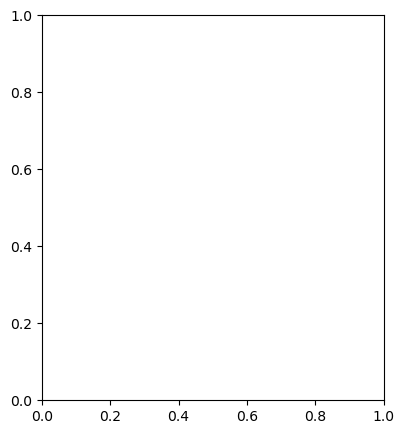

In [ ]:

# Use matplotlib to visualize some predictions
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Get predictions from SVM models
pred_svm_full = svm_full.predict(X_test_full_raw)
pred_svm_bbox = svm_bbox.predict(X_test_bbox_raw)

# Draw confusion matrices for SVM models
plt.figure(figsize=(15, 5))

# Plot confusion matrix for SVM (Full Image)
plt.subplot(1, 2, 1)
plt.imshow(confusion_matrix(test_labels, pred_svm_full), interpolation='nearest', cmap='viridis')
plt.title('SVM (Full Image) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

# Plot confusion matrix for SVM (Bounding Box)
plt.subplot(1, 2, 2)
plt.imshow(confusion_matrix(test_labels, pred_svm_bbox), interpolation='nearest', cmap='viridis')
plt.title('SVM (Bounding Box) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

plt.tight_layout()
plt.show()
